
# Triadic Cell Notebook v37
## Seatability-first runtime with inverse-query vacuum

This notebook implements the next inversion.

The trick is not to solve the query head-on.
The trick is to create a **vacuum shaped like the inverse of the unresolved query** and let only
stable seats remain inside that cavity.

So instead of:

1. direct lookup and stop
2. shape lookup and stop
3. only then potential shift

v37 does this:

- **direct hit** and **shape hit** become priors
- every nontrivial case still enters a **seatability loop**
- the loop emits request-shaped pulls into an inverse-query vacuum
- branches survive only if they can keep seating without increasing contradiction

The primitive is:

$$
\text{seatability} = \text{fit under inverse constraint}
$$

This is the first notebook in the line where:
- lookup becomes a prior, not an exit
- the vacuum is primary
- the answer emerges as the only branch that can remain seated



## Practical meaning

This is still runtime control, not base-model training.

The runtime now has one primary question:

> which branch can keep seating inside the inverse-shaped vacuum?

Direct memory hits and shape matches are still useful, but they only initialize the basin.
They do not get to end the computation early.

Main outputs:
- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `vacuum_summary`
- `vacuum_trace_df`


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)
print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a, b):
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape, local_mold, alpha=0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Directional basis


In [3]:

raw_basis = np.array([
    [1.0, 0.0, 0.6, 0.2, 0.0, 0.3],
    [0.2, 1.0, 0.0, 0.6, 0.2, 0.0],
    [0.0, 0.2, 1.0, 0.0, 0.6, 0.2],
    [0.6, 0.0, 0.2, 1.0, 0.0, 0.6],
    [0.0, 0.6, 0.2, 0.0, 1.0, 0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)


## Query corruption


In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls, mode):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.015, size=q.shape[0])
    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.45
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])
    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])
    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.56 * target + 0.44 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])
    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Core fold decomposition


In [5]:

def directional_coeffs(x):
    return U @ x

def reconstruct_from_coeffs(c):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query, target):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    return {
        "R": R,
        "M": M,
        "E": E,
        "aligned_ratio": float(aligned_energy / total_energy),
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
    }



## Candidate evaluation and field emission


In [6]:

def triadic_evaluate(query, cls):
    s0, s1, s2 = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.45 * (1.0 - retrieve_fit)
    )

    declaration_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.95 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.45 * bridge_energy
    )

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "missing_ratio": split["missing_ratio"],
        "excess_ratio": split["excess_ratio"],
        "declared_value": projected2,
    }

def triadic_query(query):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin

def produce_fields_for_class(query, cls):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)

    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])

    retrieve_mask = normalize01(ev["R"])
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": cls,
        "margin": margin,
        "retrieve_fit": ev["retrieve_fit"],
        "bridge_energy": ev["bridge_energy"],
        "declaration_score": ev["declaration_score"],
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
    }

def produce_fields_best(query):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"])



## Observable map, request shape, and inverse-query vacuum


In [7]:

obs_dim = 3

OBS_W = np.array([
    [0.80, 0.10, 0.35, 0.05, 0.20, 0.10],
    [0.10, 0.75, 0.10, 0.30, 0.05, 0.25],
    [0.20, 0.10, 0.55, 0.10, 0.45, 0.20],
], dtype=float)

def observable_from_declared(declared_value):
    o = OBS_W @ declared_value
    return normalize01(o)

def build_inverse_vacuum(query, fields):
    inv_query = 1.0 - query
    contradiction = fields["contradiction_mask"]
    vacuum = normalize01(0.75 * inv_query + 0.25 * contradiction)
    return vacuum

def build_request_shape(query, fields, top_k=1):
    pred_obs = observable_from_declared(fields["declared_value"])
    vacuum = build_inverse_vacuum(query, fields)
    vacuum_obs = normalize01(OBS_W @ vacuum)

    request_scores = vacuum_obs * (1.0 - pred_obs)
    idx = np.argsort(request_scores)[-top_k:]

    mask = np.zeros(obs_dim, dtype=float)
    mask[idx] = 1.0

    tolerance = 0.10 + 0.25 * float(fields["contradiction_mask"].mean())
    priority = float(vacuum.mean())

    return {
        "mask": mask,
        "expected_profile": pred_obs,
        "vacuum_obs": vacuum_obs,
        "tolerance": tolerance,
        "priority": priority,
    }

def provider_pull(true_cls, request_shape):
    full_obs = observable_from_declared(chains[true_cls][2])
    mask = request_shape["mask"]
    packet = full_obs * mask + rng.normal(0.0, 0.02, size=full_obs.shape[0]) * mask
    return normalize01(packet)



## Priors


In [8]:

DIRECT_THRESHOLD = 0.985
SHAPE_THRESHOLD = 0.78

def direct_lookup_score(query):
    scores = [(cls, cosine_similarity(query, chains[cls][0])) for cls in range(n_classes)]
    scores.sort(key=lambda x: x[1], reverse=True)
    cls, score = scores[0]
    return {"class": cls, "score": float(score), "hit": score >= DIRECT_THRESHOLD}

def shape_lookup_score(query):
    best, _, margin = triadic_query(query)
    return {
        "class": best["class"],
        "score": float(best["retrieve_fit"]),
        "margin": margin,
        "hit": best["retrieve_fit"] >= SHAPE_THRESHOLD,
    }



## Seatability-first runtime


In [9]:

def seat_gain(before_fields, after_fields):
    before_missing = float(before_fields["missing_mask"].mean())
    after_missing = float(after_fields["missing_mask"].mean())
    before_contra = float(before_fields["contradiction_mask"].mean())
    after_contra = float(after_fields["contradiction_mask"].mean())
    before_decl = float(before_fields["declaration_score"])
    after_decl = float(after_fields["declaration_score"])

    return float(
        0.60 * (before_missing - after_missing)
        - 0.25 * (after_contra - before_contra)
        + 0.15 * (after_decl - before_decl)
    )

def seatability_first_runtime(query, true_cls, cycles=4, beam_width=3, exhale_steps=2, step_size=0.45, damping=0.85):
    direct = direct_lookup_score(query)
    shape = shape_lookup_score(query)

    seed_scores = {}
    seed_scores[direct["class"]] = seed_scores.get(direct["class"], 0.0) + 0.60 * direct["score"]
    seed_scores[shape["class"]] = seed_scores.get(shape["class"], 0.0) + 0.50 * shape["score"]

    decl_sorted = sorted(
        [(cls, triadic_evaluate(query, cls)["declaration_score"]) for cls in range(n_classes)],
        key=lambda x: x[1],
        reverse=True
    )[:beam_width]

    for cls, score in decl_sorted:
        seed_scores[cls] = seed_scores.get(cls, 0.0) + 0.40 * score

    init_classes = [k for k, _ in sorted(seed_scores.items(), key=lambda x: x[1], reverse=True)[:beam_width]]
    beam = [{"cls": cls, "query": query.copy(), "spawn_from": -1} for cls in init_classes]

    trace_rows = []

    for cycle in range(cycles):
        expanded = []

        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]

            for _ in range(exhale_steps):
                f_before = produce_fields_for_class(q, cls)
                request = build_request_shape(q, f_before, top_k=1)
                packet = provider_pull(true_cls, request)

                packet_back = normalize01(request["mask"] @ OBS_W)
                vacuum = build_inverse_vacuum(q, f_before)
                vacuum_push = normalize01(0.5 * packet_back + 0.5 * vacuum)

                update = step_size * (0.6 * f_before["signed_correction"] + 0.4 * vacuum_push)
                q_new = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))
                q = q_new

            expanded.append({"cls": cls, "query": q.copy(), "spawn_from": branch["spawn_from"]})

            alt_scores = sorted(
                [(c, triadic_evaluate(q, c)["declaration_score"]) for c in range(n_classes)],
                key=lambda x: x[1],
                reverse=True
            )[:2]
            for alt_cls, _ in alt_scores:
                if alt_cls != cls:
                    expanded.append({"cls": alt_cls, "query": q.copy(), "spawn_from": cls})

        scored = []
        for item in expanded:
            f_before = produce_fields_for_class(item["query"], item["cls"])
            request = build_request_shape(item["query"], f_before, top_k=1)
            packet = provider_pull(true_cls, request)
            pred_obs = observable_from_declared(f_before["declared_value"])
            obs_misfit = float(np.mean(np.abs(request["mask"] * (packet - pred_obs))))

            packet_back = normalize01(request["mask"] @ OBS_W)
            vacuum = build_inverse_vacuum(item["query"], f_before)
            vacuum_push = normalize01(0.5 * packet_back + 0.5 * vacuum)
            q_test = normalize01(item["query"] + 0.25 * (0.6 * f_before["signed_correction"] + 0.4 * vacuum_push))
            f_after = produce_fields_for_class(q_test, item["cls"])
            sg = seat_gain(f_before, f_after)

            energy = (
                0.85 * float(f_before["missing_mask"].mean())
                + 0.55 * float(f_before["contradiction_mask"].mean())
                - 0.75 * float(f_before["declaration_score"])
                - 0.25 * float(f_before["retrieve_mask"].mean())
                + 0.75 * obs_misfit
                - 0.55 * sg
            )

            scored.append({
                **item,
                "energy": float(energy),
                "seat_gain": sg,
                "missing_mass": float(f_before["missing_mask"].mean()),
                "retrieve_mass": float(f_before["retrieve_mask"].mean()),
                "contradiction_mass": float(f_before["contradiction_mask"].mean()),
                "declaration_score": float(f_before["declaration_score"]),
                "obs_misfit": obs_misfit,
                "request_mask_0": float(request["mask"][0]),
                "request_mask_1": float(request["mask"][1]),
                "request_mask_2": float(request["mask"][2]),
                "vacuum_obs_0": float(request["vacuum_obs"][0]),
                "vacuum_obs_1": float(request["vacuum_obs"][1]),
                "vacuum_obs_2": float(request["vacuum_obs"][2]),
                "obs_packet_0": float(packet[0]),
                "obs_packet_1": float(packet[1]),
                "obs_packet_2": float(packet[2]),
            })

        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["energy"] < best_per_class[cls]["energy"]:
                best_per_class[cls] = item

        beam = sorted(best_per_class.values(), key=lambda x: x["energy"])[:beam_width]

        for rank, item in enumerate(beam):
            trace_rows.append({
                "cycle": cycle,
                "beam_rank": rank,
                "class": item["cls"],
                "energy": item["energy"],
                "seat_gain": item["seat_gain"],
                "missing_mass": item["missing_mass"],
                "retrieve_mass": item["retrieve_mass"],
                "contradiction_mass": item["contradiction_mass"],
                "declaration_score": item["declaration_score"],
                "obs_misfit": item["obs_misfit"],
                "request_mask_0": item["request_mask_0"],
                "request_mask_1": item["request_mask_1"],
                "request_mask_2": item["request_mask_2"],
                "vacuum_obs_0": item["vacuum_obs_0"],
                "vacuum_obs_1": item["vacuum_obs_1"],
                "vacuum_obs_2": item["vacuum_obs_2"],
                "obs_packet_0": item["obs_packet_0"],
                "obs_packet_1": item["obs_packet_1"],
                "obs_packet_2": item["obs_packet_2"],
                "spawn_from": item["spawn_from"],
            })

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"])

    return {
        "predicted_class": final_fields["predicted_class"],
        "fields": final_fields,
        "trace_df": pd.DataFrame(trace_rows),
        "direct_prior_class": direct["class"],
        "shape_prior_class": shape["class"],
        "direct_hit": direct["hit"],
        "shape_hit": shape["hit"],
    }



## Single example


In [10]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

result = seatability_first_runtime(q0, true_cls=example_cls)
vacuum_trace_df = result["trace_df"]

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "predicted_class": result["predicted_class"],
    "direct_prior_class": result["direct_prior_class"],
    "shape_prior_class": result["shape_prior_class"],
    "direct_hit": result["direct_hit"],
    "shape_hit": result["shape_hit"],
    "retrieve_mass": float(result["fields"]["retrieve_mask"].mean()),
    "missing_mass": float(result["fields"]["missing_mask"].mean()),
    "declaration_score": float(result["fields"]["declaration_score"]),
    "trace_steps": int(len(vacuum_trace_df)),
}])
single_example


,true_class,query_mode,predicted_class,direct_prior_class,shape_prior_class,direct_hit,shape_hit,retrieve_mass,missing_mass,declaration_score,trace_steps
0,1,partial,3,3,3,False,True,0.658304,0.341696,0.452474,12


In [11]:

vacuum_trace_df.head(12)


,cycle,beam_rank,class,energy,seat_gain,missing_mass,retrieve_mass,contradiction_mass,declaration_score,obs_misfit,request_mask_0,request_mask_1,request_mask_2,vacuum_obs_0,vacuum_obs_1,vacuum_obs_2,obs_packet_0,obs_packet_1,obs_packet_2,spawn_from
0,0,0,3,0.149634,0.103779,0.510000,0.490000,0.024331,0.165064,0.008171,1.0,0.0,0.0,1.000000,0.982775,1.000000,0.462995,0.000000,0.0,-1
1,0,1,2,0.515953,0.106065,0.485504,0.514496,0.088797,-0.175306,0.146555,0.0,1.0,0.0,1.000000,1.000000,1.000000,0.000000,0.867948,0.0,-1
2,0,2,0,0.773341,0.185909,0.687730,0.312270,0.126398,-0.250978,0.148447,0.0,1.0,0.0,1.000000,1.000000,1.000000,0.000000,0.889394,0.0,-1
3,1,0,3,0.020084,0.088798,0.456699,0.543301,0.027106,0.294055,0.029583,1.0,0.0,0.0,0.986208,0.935842,0.989423,0.413188,0.000000,0.0,-1
4,1,1,2,0.341460,0.077650,0.428498,0.571501,0.092956,0.002822,0.151747,0.0,1.0,0.0,0.993580,0.975906,0.983061,0.000000,0.894694,0.0,-1
5,1,2,0,0.522248,0.152802,0.574891,0.425109,0.127218,-0.060815,0.144438,0.0,1.0,0.0,0.982986,0.980159,1.000000,0.000000,0.878564,0.0,-1
6,2,0,3,-0.105312,0.066591,0.392785,0.607215,0.030596,0.391036,0.034264,1.0,0.0,0.0,0.947332,0.893385,0.955752,0.413037,0.000000,0.0,-1
7,2,1,2,0.186892,0.064779,0.384081,0.615919,0.096879,0.137532,0.133195,0.0,1.0,0.0,0.956488,0.939479,0.938773,0.000000,0.850205,0.0,-1
8,2,2,0,0.311772,0.108223,0.460979,0.539021,0.127994,0.084153,0.142581,0.0,1.0,0.0,0.936263,0.942010,0.995528,0.000000,0.874161,0.0,-1
9,3,0,3,-0.202814,0.057670,0.341696,0.658304,0.047055,0.452474,0.022019,1.0,0.0,0.0,0.921141,0.857223,0.930268,0.460097,0.000000,0.0,-1



## Baseline compare


In [12]:

def three_stage_like_v36(query, true_cls):
    direct = direct_lookup_score(query)
    if direct["hit"]:
        fields = produce_fields_for_class(query, direct["class"])
        return {"predicted_class": direct["class"], "fields": fields, "resolved_stage": "direct_lookup"}

    shape = shape_lookup_score(query)
    if shape["hit"]:
        fields = produce_fields_for_class(query, shape["class"])
        return {"predicted_class": shape["class"], "fields": fields, "resolved_stage": "shape_lookup"}

    out = seatability_first_runtime(query, true_cls=true_cls)
    return {"predicted_class": out["predicted_class"], "fields": out["fields"], "resolved_stage": "potential_shift"}

rows_compare = []

for true_cls in range(n_classes):
    for _ in range(350):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(true_cls, mode)

        first = produce_fields_best(q)
        v36_like = three_stage_like_v36(q, true_cls=true_cls)
        v37 = seatability_first_runtime(q, true_cls=true_cls)

        rows_compare.append({
            "true_class": true_cls,
            "query_mode": mode,
            "first_correct": int(first["predicted_class"] == true_cls),
            "v36_like_correct": int(v36_like["predicted_class"] == true_cls),
            "v37_correct": int(v37["predicted_class"] == true_cls),
            "first_missing_mass": float(first["missing_mask"].mean()),
            "v36_like_missing_mass": float(v36_like["fields"]["missing_mask"].mean()),
            "v37_missing_mass": float(v37["fields"]["missing_mask"].mean()),
            "first_retrieve_mass": float(first["retrieve_mask"].mean()),
            "v36_like_retrieve_mass": float(v36_like["fields"]["retrieve_mask"].mean()),
            "v37_retrieve_mass": float(v37["fields"]["retrieve_mask"].mean()),
            "v36_like_stage": v36_like["resolved_stage"],
        })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_correct,v36_like_correct,v37_correct,first_missing_mass,v36_like_missing_mass,v37_missing_mass,first_retrieve_mass,v36_like_retrieve_mass,v37_retrieve_mass,v36_like_stage
0,0,ambiguous,1,1,1,0.376172,0.376172,0.155928,0.623828,0.623828,0.844072,shape_lookup
1,0,noisy,1,1,1,0.044923,0.044923,0.028773,0.955077,0.955077,0.971227,shape_lookup
2,0,partial,1,1,1,0.393250,0.393250,0.116121,0.606750,0.606750,0.883879,shape_lookup
3,0,ambiguous,1,1,1,0.335901,0.335901,0.135911,0.664099,0.664099,0.864089,shape_lookup
4,0,ambiguous,1,1,1,0.280167,0.280167,0.133896,0.719833,0.719833,0.866104,shape_lookup



## Core comparison


In [13]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "v36_like_accuracy": float(compare_df["v36_like_correct"].mean()),
    "v37_accuracy": float(compare_df["v37_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "v36_like_missing_mass": float(compare_df["v36_like_missing_mass"].mean()),
    "v37_missing_mass": float(compare_df["v37_missing_mass"].mean()),
    "v36_direct_fraction": float((compare_df["v36_like_stage"] == "direct_lookup").mean()),
    "v36_shape_fraction": float((compare_df["v36_like_stage"] == "shape_lookup").mean()),
    "v36_potential_fraction": float((compare_df["v36_like_stage"] == "potential_shift").mean()),
}])
compare_summary


,first_pass_accuracy,v36_like_accuracy,v37_accuracy,first_pass_missing_mass,v36_like_missing_mass,v37_missing_mass,v36_direct_fraction,v36_shape_fraction,v36_potential_fraction
0,0.842143,0.846429,0.842857,0.285874,0.249168,0.10004,0.405714,0.498571,0.095714


In [14]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct",
        "v36_like_correct",
        "v37_correct",
        "first_missing_mass",
        "v36_like_missing_mass",
        "v37_missing_mass",
        "first_retrieve_mass",
        "v36_like_retrieve_mass",
        "v37_retrieve_mass",
    ]]
    .mean()
    .reset_index()
)

by_mode_compare["v37_vs_first_gain"] = by_mode_compare["v37_correct"] - by_mode_compare["first_correct"]
by_mode_compare["v37_vs_v36_gain"] = by_mode_compare["v37_correct"] - by_mode_compare["v36_like_correct"]
by_mode_compare["v37_missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["v37_missing_mass"]

by_mode_compare = by_mode_compare.sort_values("v37_vs_first_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,v36_like_correct,v37_correct,first_missing_mass,v36_like_missing_mass,v37_missing_mass,first_retrieve_mass,v36_like_retrieve_mass,v37_retrieve_mass,v37_vs_first_gain,v37_vs_v36_gain,v37_missing_drop
4,partial,0.534351,0.549618,0.554707,0.566883,0.452735,0.202841,0.432693,0.546840,0.786981,0.020356,0.005089,0.364042
3,noisy,1.000000,1.000000,1.000000,0.170399,0.170399,0.032603,0.825468,0.825468,0.937093,0.000000,0.000000,0.137796
1,existing,1.000000,1.000000,1.000000,0.062112,0.062112,0.003519,0.933258,0.933258,0.959444,0.000000,0.000000,0.058593
0,ambiguous,0.968379,0.968379,0.952569,0.292098,0.292098,0.122096,0.698679,0.698679,0.836402,-0.015810,-0.015810,0.170002
2,inverse_hint,0.802632,0.802632,0.782895,0.262772,0.219823,0.133503,0.726262,0.764826,0.843470,-0.019737,-0.019737,0.129269



## Partial-only focus


In [15]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()

partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_v36_like_accuracy": float(partial_df["v36_like_correct"].mean()),
    "partial_v37_accuracy": float(partial_df["v37_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_v36_like_missing_mass": float(partial_df["v36_like_missing_mass"].mean()),
    "partial_v37_missing_mass": float(partial_df["v37_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_v36_like_retrieve_mass": float(partial_df["v36_like_retrieve_mass"].mean()),
    "partial_v37_retrieve_mass": float(partial_df["v37_retrieve_mass"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_v36_like_accuracy,partial_v37_accuracy,partial_first_missing_mass,partial_v36_like_missing_mass,partial_v37_missing_mass,partial_first_retrieve_mass,partial_v36_like_retrieve_mass,partial_v37_retrieve_mass
0,0.534351,0.549618,0.554707,0.566883,0.452735,0.202841,0.432693,0.54684,0.786981



## Vacuum observables


In [16]:

vacuum_summary = pd.DataFrame([{
    "mean_seat_gain": float(vacuum_trace_df["seat_gain"].mean()) if len(vacuum_trace_df) else np.nan,
    "mean_obs_misfit": float(vacuum_trace_df["obs_misfit"].mean()) if len(vacuum_trace_df) else np.nan,
    "mean_vacuum_obs_0": float(vacuum_trace_df["vacuum_obs_0"].mean()) if len(vacuum_trace_df) else np.nan,
    "mean_vacuum_obs_1": float(vacuum_trace_df["vacuum_obs_1"].mean()) if len(vacuum_trace_df) else np.nan,
    "mean_vacuum_obs_2": float(vacuum_trace_df["vacuum_obs_2"].mean()) if len(vacuum_trace_df) else np.nan,
}])
vacuum_summary


,mean_seat_gain,mean_obs_misfit,mean_vacuum_obs_0,mean_vacuum_obs_1,mean_vacuum_obs_2
0,0.09676,0.102976,0.961767,0.943636,0.971491



## Visual readout


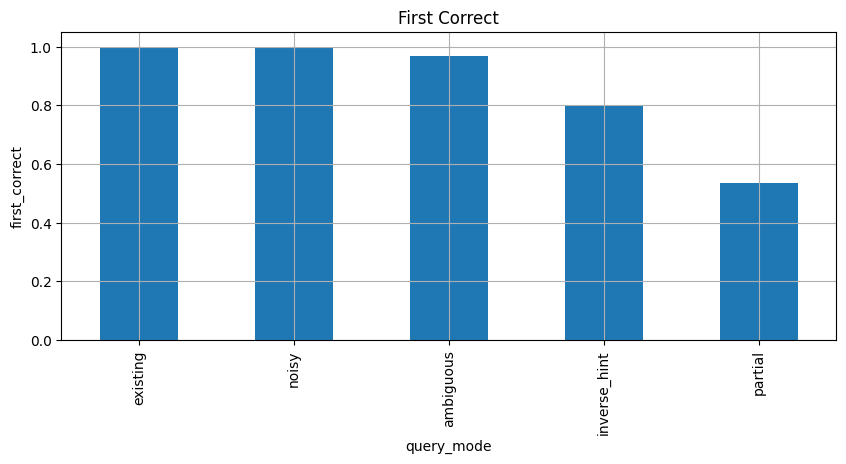

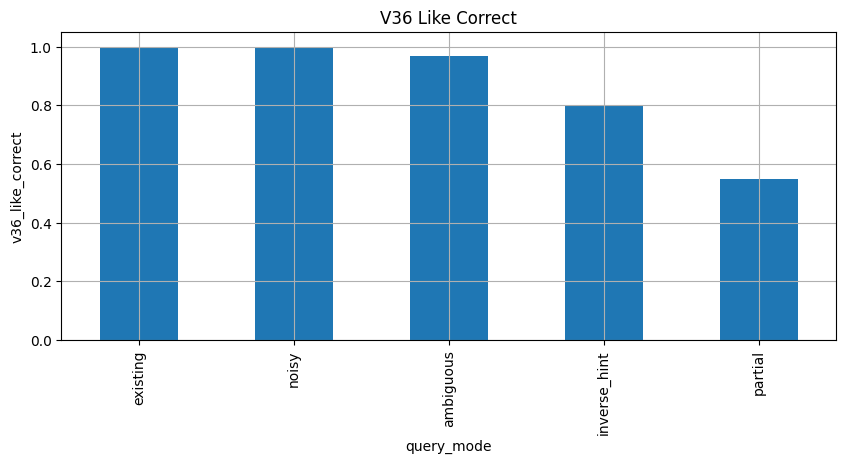

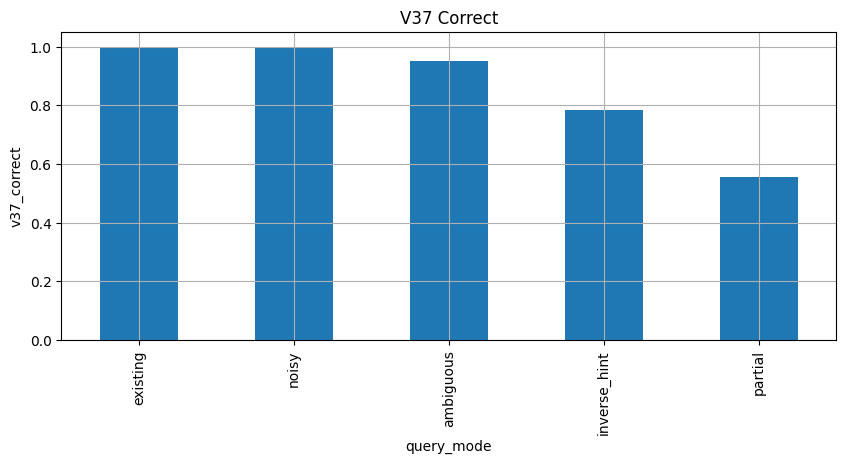

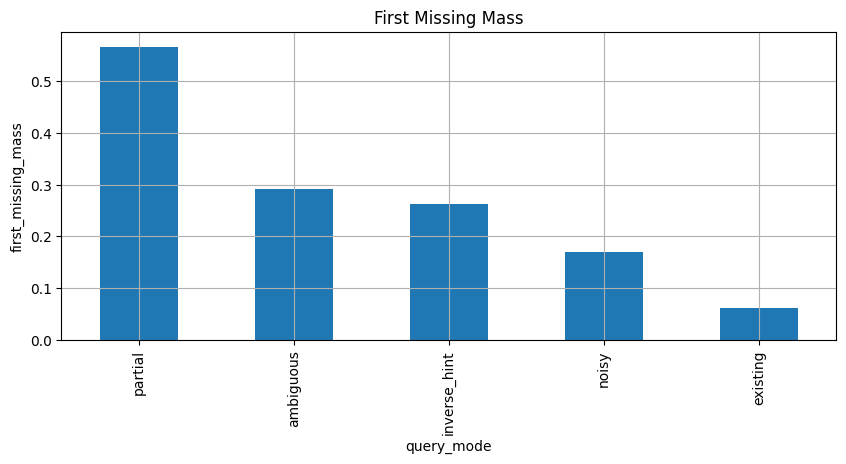

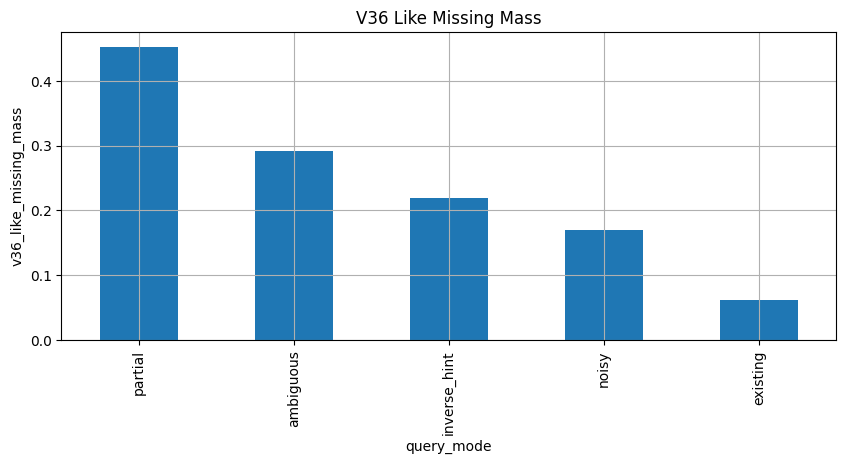

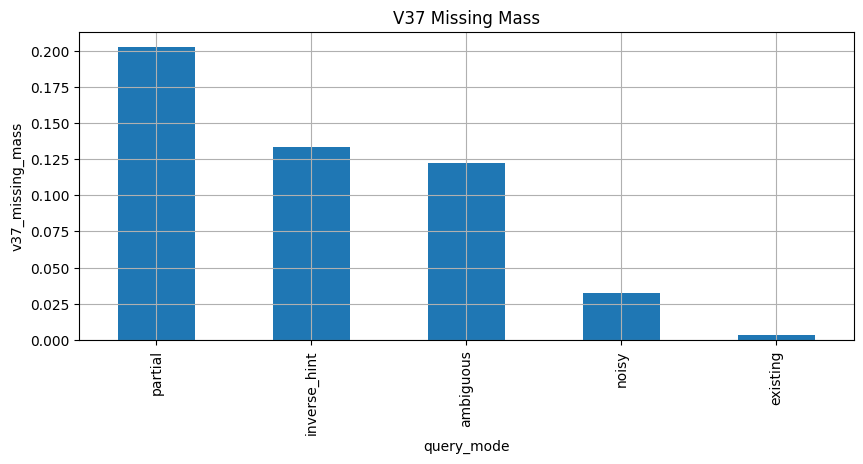

In [17]:

metrics = [
    "first_correct",
    "v36_like_correct",
    "v37_correct",
    "first_missing_mass",
    "v36_like_missing_mass",
    "v37_missing_mass",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()


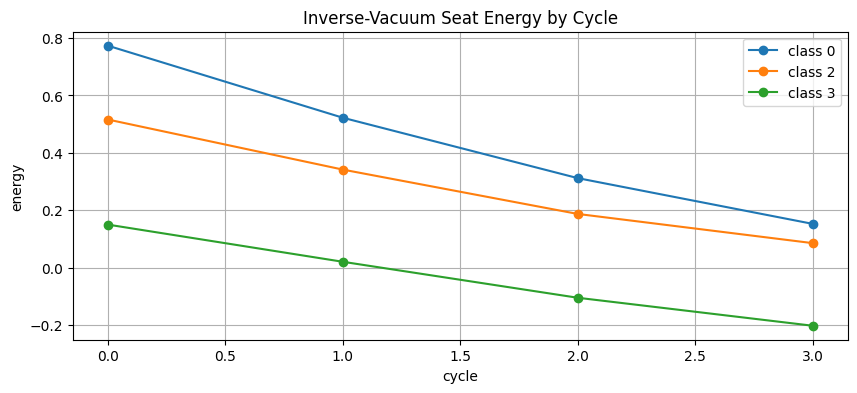

In [18]:

if len(vacuum_trace_df):
    plt.figure(figsize=(10, 4))
    for cls in sorted(vacuum_trace_df["class"].unique()):
        df = vacuum_trace_df[vacuum_trace_df["class"] == cls]
        plt.plot(df["cycle"], df["energy"], marker="o", label=f"class {cls}")
    plt.title("Inverse-Vacuum Seat Energy by Cycle")
    plt.xlabel("cycle")
    plt.ylabel("energy")
    plt.legend()
    plt.show()



## Practical readout

This notebook makes the inversion explicit:

- direct and shape hits are priors, not exits
- every serious case still enters the vacuum
- the answer should be the branch that keeps seating under inverse constraint

The first tables to read are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `vacuum_summary`
- `vacuum_trace_df`
